# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

Tecnológico de Monterrey

Prof Luis Eduardo Falcón Morales

### **Actividad de la semana: Modelos basados en Árboles**


**Nombre y matrícula:** Jareth Israel Rivera Pineda - A01411621


# **PARTE - A - Métricas de Clasificación**

In [24]:
# Importamos lo necesario para la actividad

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
from sklearn.dummy import DummyClassifier

np.random.seed(17)

In [25]:
# Para esta actividad vamos a generar datos sintéticos para un problema de
# clasificación binario utilizando "make_classification" de scikitlearn.


# Recuerda consultar la documentación para mayor información:
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html


# Utilizaremos los siguientes valores de los hiperparámetros de make_classification:
# - n_samples: número de muestras o registros a generar.
# - n_features: número total de características o variables de entrada X. Incluye informativas, redundantes, duplicadas.
# - n_informative: número de características informativas o independientes.
# - n_redundant: número de características redundantes.
# - weights: pesos para las clases [0,1]-->[Clase_Mayoritaria_Negativa(0), clase_minoritaria_positiva(1)].
# - class_sep: separación entre clases (menor a 1 más entrelazados. Mayor a 1, más separados).
# - n_classes: número de clases.
# - n_clusters_per_class: número de cúmulos por clase. Mayor a 1, más complejo.
# - flip_y: fracción de ejemplos cuya clase se cambia aleatoriamente (ruido) para hacerlo más complejo.
# - random_state: semilla para reproducibilidad.

X, y = make_classification(
    n_samples=10_000,          # 10,000 registros
    n_features=20,             # factores en total
    n_informative=15,          # factores informativos o variables de entrada independientes
    n_redundant=5,             # factores redundantes (dependientes). Para añadir complejidad usamos valor > 0
    weights=[0.88, 0.12],      # Desbalance de clases: Mayoritaria clase 0; minoritaria clase 1
    class_sep=1.0,             # Separación entre clases
    n_classes=2,               # Dos clases
    n_clusters_per_class=1,    # Para agregar complejidad adicional considera valores > 1
    flip_y=0.01,               # Añadir algo de ruido. default 0.01
    random_state=17,           # semilla para la repetibilidad
)

In [26]:
# Lo definimos como un DataFrame de Pandas para su mejor manejo:
feature_names = [f'feature_{i+1}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Total de registros generados: {len(df)}")
print(f"Distribución de clases: {df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")
print(f"Cantidad de factores: {len(feature_names)}")

Total de registros generados: 10000
Distribución de clases: target
0    87.7%
1    12.3%
Name: proportion, dtype: object
Cantidad de factores: 20


In [27]:
pd.DataFrame(df).describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,10000.0,1.016138,2.243319,-6.429702,-0.520059,1.025274,2.535350,9.286981
feature_2,10000.0,0.785670,1.994150,-8.578184,-0.462409,0.851269,2.137617,7.937184
feature_3,10000.0,-0.757783,2.127136,-9.574402,-2.200615,-0.782594,0.630210,9.676054
feature_4,10000.0,1.733561,4.820216,-19.158886,-1.578108,1.751568,5.036626,19.051885
feature_5,10000.0,1.004263,2.309019,-6.665816,-0.540579,0.990261,2.538778,9.991830
feature_6,10000.0,-0.758315,2.682632,-11.246005,-2.561001,-0.780123,1.025289,10.297298
feature_7,10000.0,-0.448463,5.527866,-24.457356,-4.152116,-0.447135,3.285445,21.695749
feature_8,10000.0,0.974038,2.446141,-7.820102,-0.651334,0.977687,2.634129,11.292973
feature_9,10000.0,-0.769954,2.546797,-11.410437,-2.475215,-0.740625,0.947244,7.435675
feature_10,10000.0,0.739749,2.267579,-7.860020,-0.747975,0.768796,2.290440,9.363365


In [28]:
# Separamos las variables de entrada y la variable objetivo de salida:
X = df.drop('target', axis=1).values
y = df['target'].values

# Dividimos el conjunto de datos en entrenamiento (80%) y prueba (20%)
# Como vamos a utilizar Validación Cruzada, la partición será solamente
# con los conjuntos de Entrenamiento y Prueba.
# Además usamos "stratify" para mantener la proporción de clases en la partición.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 8000 muestras
Tamaño del conjunto de prueba: 2000 muestras


In [29]:
# Obtengamos los siguientes resultados con la función Dummy,
# con una partición provisional para el Dummy:

Xt, Xv, yt, yv = train_test_split(X_train, y_train, test_size=0.2, random_state=17, stratify=y_train)

estrategias = ['most_frequent','prior','stratified','uniform']

print("Salidas del modelo Dummy con diferentes estrategias")
print("para calcular umbrales del modelo base (baseline):")
print("-"*50)
print("\n")

for estrategia in estrategias:
  dummy_clf = DummyClassifier(strategy=estrategia, random_state=17)
  dummy_clf.fit(Xt, yt)
  y_pred = dummy_clf.predict(Xv)

  # Tabla para almacenar resultados
  results = []

  # "pos_label" indica la clase con respecto a la cual evaluar cada métrica.
  acc = accuracy_score(yv, y_pred)
  rec = recall_score(yv, y_pred, pos_label=1)
  prec = precision_score(yv, y_pred, pos_label=1)
  f1_sc = f1_score(yv, y_pred, pos_label=1)

  results.append({'Accuracy': acc,
                'Recall': rec,
                'Precision': prec,
                'F1 Score': f1_sc
                })

  print(f"Estrategia: {estrategia}")
  print(f"Accuracy: {acc:.4f}")
  print(f"Recall: {rec:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"F1 Score: {f1_sc:.4f}")

  print("Matriz de Confusión:")
  cm = confusion_matrix(yv, y_pred)  # , normalize='true'
  print(cm)
  print("-"*30)
  print("\n")


Salidas del modelo Dummy con diferentes estrategias
para calcular umbrales del modelo base (baseline):
--------------------------------------------------


Estrategia: most_frequent
Accuracy: 0.8769
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1403    0]
 [ 197    0]]
------------------------------


Estrategia: prior
Accuracy: 0.8769
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1403    0]
 [ 197    0]]
------------------------------


Estrategia: stratified
Accuracy: 0.8006
Recall: 0.1015
Precision: 0.1235
F1 Score: 0.1114
Matriz de Confusión:
[[1261  142]
 [ 177   20]]
------------------------------


Estrategia: uniform
Accuracy: 0.4856
Recall: 0.4670
Precision: 0.1136
F1 Score: 0.1827
Matriz de Confusión:
[[685 718]
 [105  92]]
------------------------------




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Ejercicio - 1**


**En la salida anterior se obtuvieron dos advertencias (warnings).**

* **1a) ¿A cuáles casos de las estrategias Dummy están asociadas esas advertencias?**

* **1b) Explica qué significan esas advertencias y relaciona la explicación con los valores de las matrices de confusión correspondientes.**

* **1c) ¿Por qué en este caso no escalamos los datos de entrada?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* 1a) Las advertencias (warnings) están asociadas a las estrategias: **most_frequent** y **prior**

* 1b) Las advertencias aparecen en **most_frequent** y **prior** porque el modelo no predice ningún caso de la clase 1.

En la matriz de confusión se ve que todos los positivos reales (197) fueron clasificados como 0 y no hay verdaderos positivos (TP = 0).

Por eso el recall es 0 y la precision no puede calcularse correctamente (división entre cero), lo que genera el warning.

* 1c) No escalamos los datos porque estamos usando DummyClassifier, que no aprende de las variables ni usa distancias o magnitudes.

Sus predicciones dependen solo de reglas simples (como la clase más frecuente), así que el escalado no cambia nada.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

## **Ejercicio - 2**

**Sabemos que tenemos un problema de clases desbalanceadas y debiéramos utilizar otra métrica que nos ayude a medir mejor el desempeño del modelo. Indica en cada uno de los siguientes incisos cuál sería el valor del modelo base (baseline) que debiéramos utilizar, de acuerdo a la métrica que se indica:**


++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++


* 2a) Accuracy: 0.8769 (estrategia most_frequent o prior)

* 2b) Precision: 0.1235 (estrategia stratified)

* 2c) Recall: 0.4670 (estrategia uniform)

* 2d) F1-Score: F1-Score: 0.1827 (estrategia uniform)

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **PARTE - B - XGBoost**

### **En el siguiente ejercicio explorarás el efecto de algunos de los argumentos del modelo XGBoost.**

### Puedes consultar la documentación:

https://xgboost.readthedocs.io/en/latest/python/python_api.html

Usaremos la base de datos llamada breast-cancer:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html


https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

## **Ejercicio - 3**

### **Describe en qué consiste la base de datos breast_cancer.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

La base de datos breast_cancer es un conjunto de datos para un problema de clasificación binaria relacionado con el diagnóstico de cáncer de mama.

Contiene 569 muestras obtenidas de imágenes digitalizadas de biopsias, donde cada registro incluye 30 características numéricas que describen propiedades del tumor (como radio, textura, perímetro, área, suavidad, entre otras).

La variable objetivo tiene dos clases:

0 = maligno

1 = benigno

El objetivo es construir un modelo que pueda clasificar correctamente si un tumor es maligno o benigno a partir de estas características.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

In [30]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from xgboost import plot_importance, plot_tree

In [31]:
# Cargamos un dataset de ejemplo:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Dividimos en conjuntos de entrenamiento y prueba para los
# própósitos de nuestro ejercicio:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

print("Información del conjunto de entrenamiento:")
print("*"*50)
print(f"Número de características: {X_train.shape[1]}")
print(f"Número de muestras: {X_train.shape[0]}")
print(f"Distribución de clases [Maligno, Benigno]: {np.bincount(y_train)}")
print("\nPrimeras 3 filas del conjunto de entrenamiento:")
print(X_train.head(3).T)

Información del conjunto de entrenamiento:
**************************************************
Número de características: 30
Número de muestras: 455
Distribución de clases [Maligno, Benigno]: [170 285]

Primeras 3 filas del conjunto de entrenamiento:
                                285          535          521
mean radius               12.580000    20.550000    24.630000
mean texture              18.400000    20.860000    21.600000
mean perimeter            79.830000   137.800000   165.500000
mean area                489.000000  1308.000000  1841.000000
mean smoothness            0.083930     0.104600     0.103000
mean compactness           0.042160     0.173900     0.210600
mean concavity             0.001860     0.208500     0.231000
mean concave points        0.002924     0.132200     0.147100
mean symmetry              0.169700     0.212700     0.199100
mean fractal dimension     0.058550     0.062510     0.067390
radius error               0.271900     0.698600     0.991500
textur

In [32]:
# Definimos nuestra función que usaremos para el ejercicio:

def mi_exploracion_xgboost(xtr=X_train, ytr=y_train, xte=X_test, yte=y_test,
               mis_estimadores=100,
               mi_learning_rate=1.,
               mi_tree_idx=3
               ):

  # Definimos nuestro modelo XGBoost básico:
  xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # Para clasificación binaria.
    nthread=-1,    # Para usar todos los recursos que se tengan.
    n_estimators= mis_estimadores,
    learning_rate= mi_learning_rate,
    random_state=17
    )

  # Aquí ajustamos/entrenamos el modelo
  xgb_model.fit(xtr, ytr)

  # Evaluamos el rendimiento:
  y_pred = xgb_model.predict(xte)

  print("\nReporte de clasificación:")
  print(classification_report(yte, y_pred, target_names=data.target_names))

  # Visualización de los árboles:
  plt.figure(figsize=(18, 24))
  plot_tree(xgb_model,
            tree_idx= mi_tree_idx
            )

  plt.title('tree_idx={}\nestimators={}\nlearning_rate={}'.format(mi_tree_idx,mis_estimadores,mi_learning_rate))
  plt.tight_layout()
  plt.show()


## **Ejercicio - 4**

**Utiliza la función mi_exploracion_xgboost() definida peviamente para responder a los siguientes incisos:**

* **4a) ¿Cuál es, en general, el efecto del argumento "mi_tree_idx" y cuál es el rango de valores que puede tomar?**

El argumento mi_tree_idx indica qué árbol del modelo XGBoost se quiere visualizar.

Como XGBoost es un modelo de ensamble basado en varios árboles, este parámetro permite observar cada árbol individualmente.

Si n_estimators=100, entonces mi_tree_idx puede tomar valores de 0 a 99.

* **4b) Modificando solamente el argumento "mi_tree_idx", muestra y explica cada una de las salidas de la función que definimos con los valores mínimo, máximo y otros dos intermedios del argumento "mi_tree_idx".**


Al modificar únicamente mi_tree_idx, observe que el árbol con índice 0 es el primero que se entrena y suele capturar patrones generales, los árboles intermedios comienzan a corregir errores del modelo previo, el último árbol (índice 99) realiza ajustes más finos sobre los errores restantes y el reporte de clasificación no cambia al modificar mi_tree_idx, ya que el modelo completo es el mismo.

Lo único que cambia es el árbol que estamos visualizando.


* **4c) Incluye tus conclusiones y en particular explica qué información nos dan estos resultados sobre la manera en que se entrena el modelo XGBoost.**

Estos resultados muestran que XGBoost entrena los árboles de manera secuencial. Cada nuevo árbol aprende de los errores cometidos por los anteriores y trata de corregirlos.

Esto confirma que XGBoost es un modelo de boosting, donde los árboles no son independientes, sino que trabajan en conjunto para mejorar progresivamente el desempeño final del modelo.


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

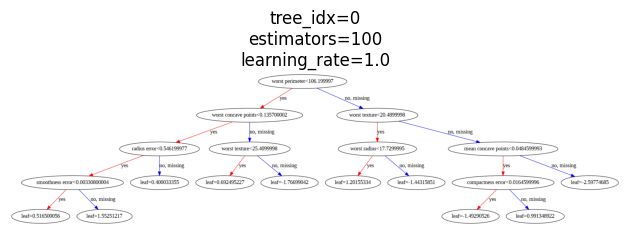


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

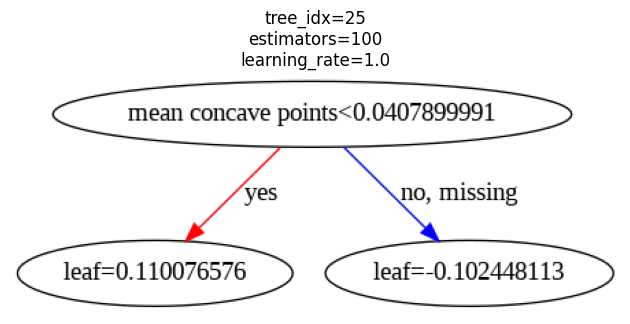


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

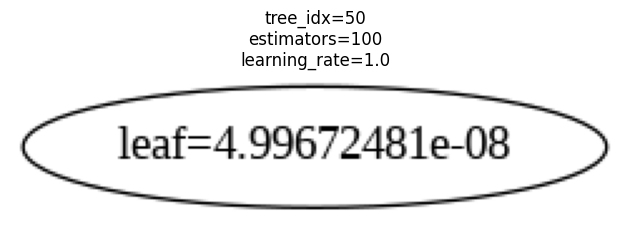


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

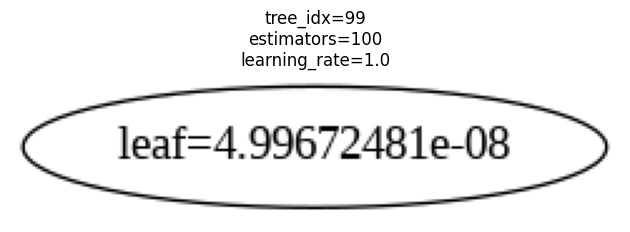

In [33]:

# Incluye todas las celdas de código y texto que consideres necesarias.

# n_estimators = 100 → tree_idx va de 0 a 99

# Valor mínimo
mi_exploracion_xgboost(mi_tree_idx=0)

# Valor intermedio 1
mi_exploracion_xgboost(mi_tree_idx=25)

# Valor intermedio 2
mi_exploracion_xgboost(mi_tree_idx=50)

# Valor máximo
mi_exploracion_xgboost(mi_tree_idx=99)


## **Ejercicio - 5**

**Utiliza la función mi_exploracion_xgboost() definida peviamente para explicar las salidas de los casos. Muestra la salida de dichos casos:**

**5a) mi_exploracion_xgboost(mi_learning_rate=10., mi_tree_idx=50).**

Es un valor extremadamente alto.
El modelo tiende a sobreajustar fuertemente porque cada árbol corrige demasiado los errores anteriores.
Esto puede generar inestabilidad y menor capacidad de generalización.

**5b) mi_exploracion_xgboost(mi_learning_rate=1., mi_tree_idx=50),**

Sigue siendo alto.
El modelo aprende muy agresivamente, lo que puede provocar sobreajuste aunque el desempeño puede parecer bueno.

**5c) mi_exploracion_xgboost(mi_learning_rate=0.1, mi_tree_idx=50),**

Es un valor más común y recomendado.
El aprendizaje es más estable y generalmente se obtiene un mejor equilibrio entre sesgo y varianza.

**5d) mi_exploracion_xgboost(mi_learning_rate=0.01, mi_tree_idx=50),**

El aprendizaje es más lento.
El modelo necesita más árboles para lograr el mismo desempeño.
Con solo 100 estimadores puede quedarse corto.

**5e) mi_exploracion_xgboost(mi_learning_rate=0.001, mi_tree_idx=50).**

Es demasiado pequeño para solo 100 árboles.
El modelo apenas aprende y puede mostrar bajo desempeño (subajuste).

* **Explica el efecto del argumento "learning_rate" y explica la salida de cada uno de estos resultados.**


El learning_rate controla cuánto contribuye cada árbol nuevo al modelo final.

* Valores altos: el modelo aprende muy rápido pero puede sobreajustar.

* Valores bajos: el aprendizaje es más lento y estable, pero puede requerir más árboles.


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

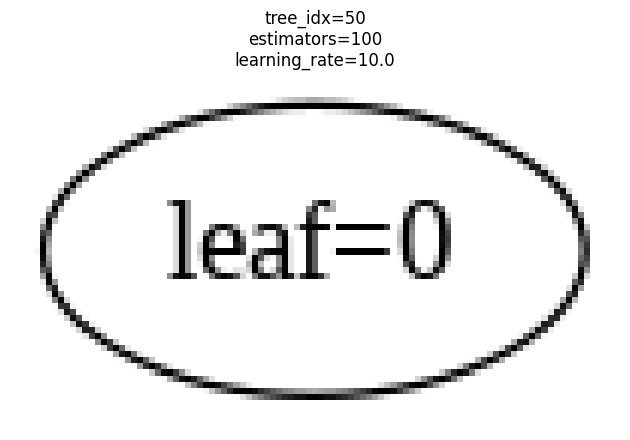


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

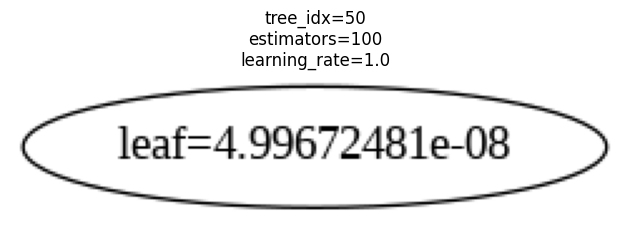


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

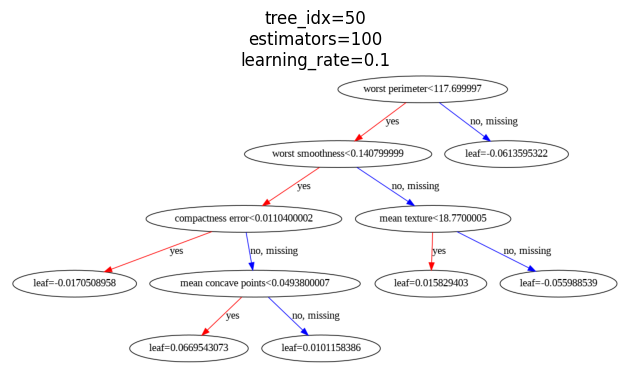


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

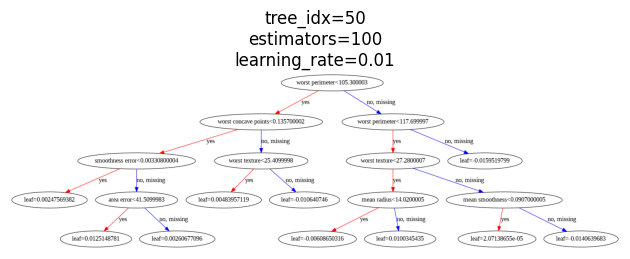


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.00      0.00      0.00        42
      benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1800x2400 with 0 Axes>

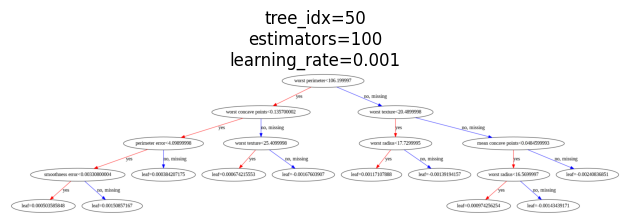

In [34]:

# Incluye todas las celdas de código y texto que consideres necesarias.

# 5a
mi_exploracion_xgboost(mi_learning_rate=10., mi_tree_idx=50)

# 5b
mi_exploracion_xgboost(mi_learning_rate=1., mi_tree_idx=50)

# 5c
mi_exploracion_xgboost(mi_learning_rate=0.1, mi_tree_idx=50)

# 5d
mi_exploracion_xgboost(mi_learning_rate=0.01, mi_tree_idx=50)

# 5e
mi_exploracion_xgboost(mi_learning_rate=0.001, mi_tree_idx=50)


## **Ejercicio - 6**

**Incluye tus comentarios finales de esta actividad:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++


En esta actividad pude observar cómo influyen distintos parámetros en el comportamiento de los modelos de clasificación.

Primero, con el modelo Dummy entendí la importancia de elegir métricas adecuadas cuando existen clases desbalanceadas, ya que la accuracy puede ser engañosa.

Después, al trabajar con XGBoost, noté cómo el modelo se construye de manera secuencial, donde cada árbol corrige los errores del anterior. También comprobé que el parámetro learning_rate es fundamental, ya que controla la velocidad de aprendizaje y puede provocar sobreajuste o subajuste dependiendo de su valor.

En general, la actividad permitió entender mejor cómo se entrena un modelo de boosting y la importancia de ajustar correctamente sus hiperparámetros para lograr un buen desempeño.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **<<Fin de la Actividad de la Semana : modelos basados en árboles>>**